In [1]:
path=

In [3]:
import pandas as pd

df = pd.read_csv(path)

print("\n--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Data Statistics ---")
print(df.describe())

print("\n--- Column Names ---")
print(df.columns)

print("\n--- Number of Rows and Columns ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


--- First 5 rows of the dataset ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Data Statistics ---
              price          area    

In [4]:
# 1. Handling Categorical Variables

# Convert 'yes'/'no' columns to 1/0
varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
def binary_map(x):
    return x.map({'yes': 1, 'no': 0})
df[varlist] = df[varlist].apply(binary_map)

# One-hot encoding for 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# 2. Normalizing Numerical Features

# Exclude 'price' as it's typically the target variable
# List of numerical variables to scale
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_vars] = scaler.fit_transform(df[num_vars])

print("\n--- DataFrame after cleaning and scaling (first 5 rows) ---")
print(df.head())

print("\n--- Data types after handling categorical variables ---")
print(df.info())


--- DataFrame after cleaning and scaling (first 5 rows) ---
      price      area  bedrooms  bathrooms   stories  mainroad  guestroom  \
0  13300000  1.046726  1.403419   1.421812  1.378217         1          0   
1  12250000  1.757010  1.403419   5.405809  2.532024         1          0   
2  12250000  2.218232  0.047278   1.421812  0.224410         1          0   
3  12215000  1.083624  1.403419   1.421812  0.224410         1          0   
4  11410000  1.046726  1.403419  -0.570187  0.224410         1          1   

   basement  hotwaterheating  airconditioning   parking  prefarea  \
0         0                0                1  1.517692         1   
1         0                0                1  2.679409         0   
2         1                0                0  1.517692         1   
3         1                0                1  2.679409         1   
4         1                0                1  1.517692         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnis

### Data Validation

In [5]:
# Check for missing values
print("\n--- Missing values per column ---")
print(df.isnull().sum())

# Check for duplicate rows
print("\n--- Number of duplicate rows ---")
print(df.duplicated().sum())


--- Missing values per column ---
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

--- Number of duplicate rows ---
0


In [6]:
# Check unique values for the newly created boolean columns
print("\n--- Unique values for furnishingstatus_semi-furnished ---")
print(df['furnishingstatus_semi-furnished'].unique())

print("\n--- Unique values for furnishingstatus_unfurnished ---")
print(df['furnishingstatus_unfurnished'].unique())

# Verify binary columns still contain only 0s and 1s
print("\n--- Unique values for mainroad ---")
print(df['mainroad'].unique())

print("\n--- Unique values for guestroom ---")
print(df['guestroom'].unique())


--- Unique values for furnishingstatus_semi-furnished ---
[False  True]

--- Unique values for furnishingstatus_unfurnished ---
[False  True]

--- Unique values for mainroad ---
[1 0]

--- Unique values for guestroom ---
[0 1]


### Model Training: Data Splitting and Linear Regression

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('price', axis=1) # All columns except 'price'
y = df['price'] # The 'price' column is the target

# Split the data into training and testing sets
# We'll use a 70/30 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (381, 13)
X_test shape: (164, 13)
y_train shape: (381,)
y_test shape: (164,)


In [8]:
from sklearn.linear_model import LinearRegression

# Initialize a basic Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Model Evaluation

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2): 0.6463
Mean Absolute Error (MAE): 920392.94
Mean Squared Error (MSE): 1523019469501.29
Root Mean Squared Error (RMSE): 1234106.75


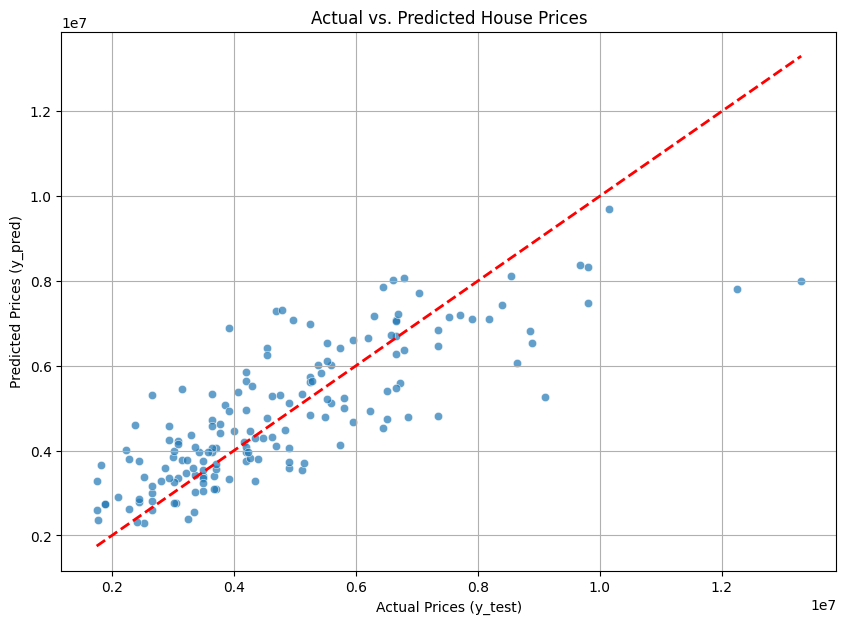

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2) # Perfect prediction line
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices (y_test)')
plt.ylabel('Predicted Prices (y_pred)')
plt.grid(True)
plt.show()